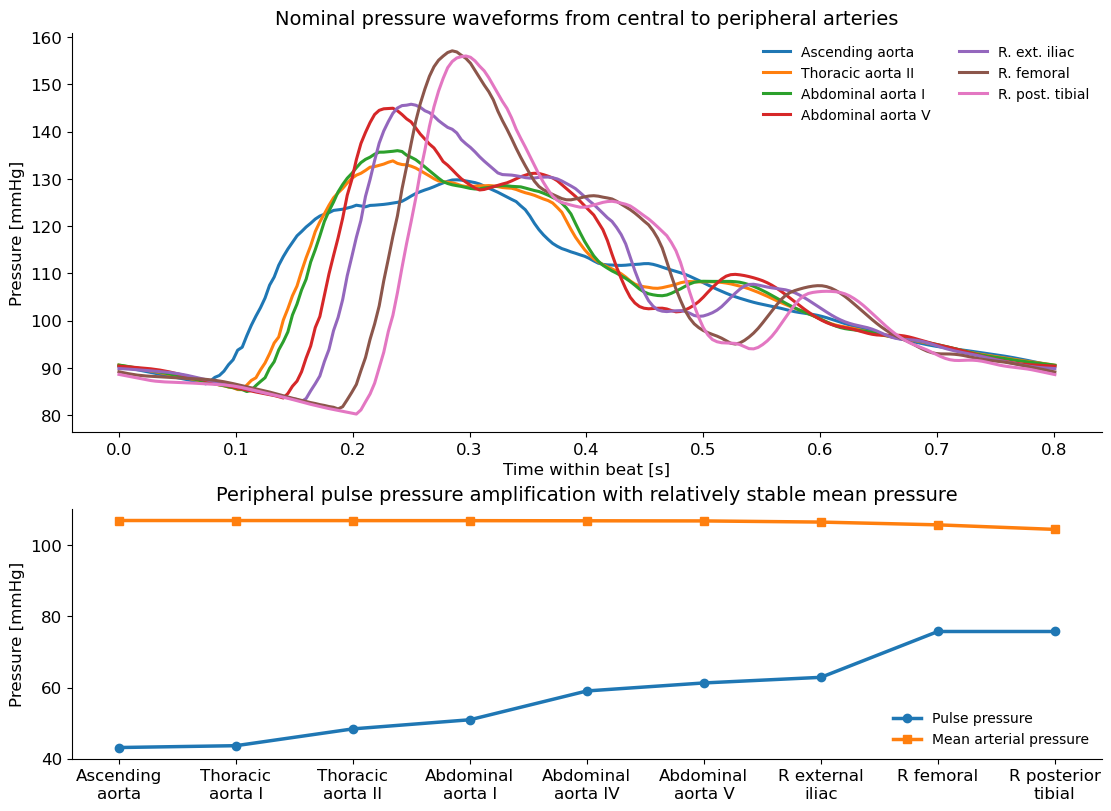

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tl55 import generate_waveforms

# -----------------------------
# Load nominal simulation
# -----------------------------
project_root = Path.cwd()
q_path = project_root / "data" / "Q_inputwave2.mat"

result = generate_waveforms(
    sv_rel=1.0,
    hr_rel=1.0,
    tpr_rel=1.0,
    e_rel=1.0,
    sl=0.0,
    pad_nodes=[],
    l_pad=1.0,
    q_input_path=q_path,
)

# Beat-local time axis for display
t_plot = result.time_s - result.time_s[0]

# Segment table
seg_df = result.effective_segments.set_index("idx")

# A central-to-peripheral path down the right leg
path_ids = [1, 12, 13, 25, 31, 33, 35, 38, 41]
path_labels = [
    "Ascending\naorta",
    "Thoracic\naorta I",
    "Thoracic\naorta II",
    "Abdominal\naorta I",
    "Abdominal\naorta IV",
    "Abdominal\naorta V",
    "R external\niliac",
    "R femoral",
    "R posterior\ntibial",
]

# Pressure traces along the path
path_pressures = result.pressure_outlet_mmHg[np.array(path_ids) - 1, :]

# Hemodynamic summaries along the path
pp_mmHg = path_pressures.max(axis=1) - path_pressures.min(axis=1)
map_mmHg = path_pressures.mean(axis=1)

# A few representative waveforms to overlay
waveform_ids = [1, 13, 25, 33, 35, 38, 41]

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
})

fig = plt.figure(figsize=(11, 8), constrained_layout=True)
gs = fig.add_gridspec(2, 1, height_ratios=[2.0, 1.25])

# -----------------------------
# Top panel: pressure waveforms
# -----------------------------
ax1 = fig.add_subplot(gs[0, 0])

for seg_idx in waveform_ids:
    seg_name = seg_df.loc[seg_idx, "name"]
    ax1.plot(
        t_plot,
        result.pressure_outlet_mmHg[seg_idx - 1, :],
        linewidth=2.2,
        label=seg_name,
    )

ax1.set_title("Nominal pressure waveforms from central to peripheral arteries")
ax1.set_xlabel("Time within beat [s]")
ax1.set_ylabel("Pressure [mmHg]")
ax1.legend(ncol=2, frameon=False)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# -----------------------------
# Bottom panel: PP and MAP trend
# -----------------------------
ax2 = fig.add_subplot(gs[1, 0])

x = np.arange(len(path_ids))
ax2.plot(x, pp_mmHg, marker="o", linewidth=2.5, label="Pulse pressure")
ax2.plot(x, map_mmHg, marker="s", linewidth=2.5, label="Mean arterial pressure")

ax2.set_title("Peripheral pulse pressure amplification with relatively stable mean pressure")
ax2.set_ylabel("Pressure [mmHg]")
ax2.set_xticks(x)
ax2.set_xticklabels(path_labels)
ax2.legend(frameon=False)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.show()

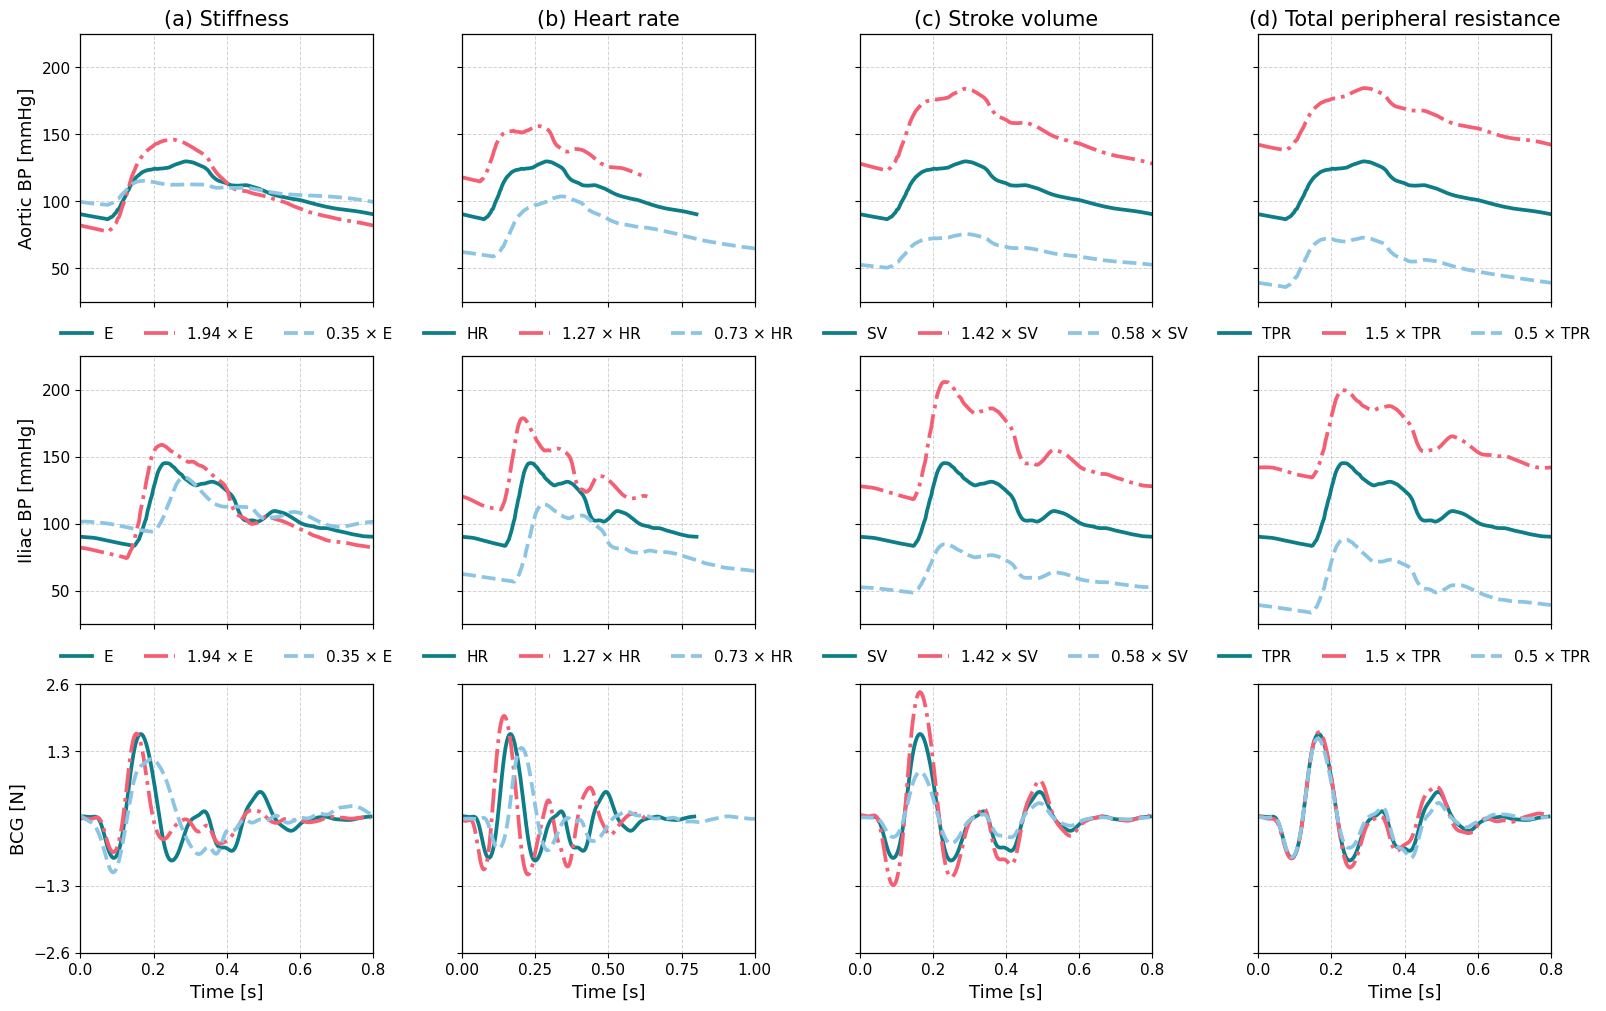

In [ ]:
# RECREATES FIG4 FROM THE PAPER 10.1109/TBME.2025.3584979.
from pathlib import Path
import matplotlib.pyplot as plt
from tl55 import generate_waveforms, generate_bcg

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
project_root = Path.cwd()
q_path = project_root / "data" / "Q_inputwave2.mat"
mv_q_path = project_root / "data" / "MV_Q_padded_2.mat"

# ------------------------------------------------------------
# One simulation helper
# ------------------------------------------------------------
def run_case(sv_rel=1.0, hr_rel=1.0, tpr_rel=1.0, e_rel=1.0,
             sl=0.0, pad_nodes=(33,), l_pad=1.0):
    wf = generate_waveforms(
        sv_rel=sv_rel,
        hr_rel=hr_rel,
        tpr_rel=tpr_rel,
        e_rel=e_rel,
        sl=sl,
        pad_nodes=list(pad_nodes),
        l_pad=l_pad,
        q_input_path=q_path,
    )
    bcg = generate_bcg(
        sv_rel=sv_rel,
        hr_rel=hr_rel,
        tpr_rel=tpr_rel,
        e_rel=e_rel,
        sl=sl,
        pad_nodes=list(pad_nodes),
        l_pad=l_pad,
        q_input_path=q_path,
        mv_q_path=mv_q_path,
    )
    return wf, bcg

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------
LW = 2.7
COLOR_H = "#F55F74"
COLOR_M = "#0D7D87"
COLOR_L = "#8CC5E3"

plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.7,
})

# ------------------------------------------------------------
# Parameter sweeps
# ------------------------------------------------------------
cases = {
    "(a) Stiffness": {
        "nom": dict(sv_rel=1.0, hr_rel=1.0, tpr_rel=1.0, e_rel=1.0),
        "high": dict(sv_rel=1.0, hr_rel=1.0, tpr_rel=1.0, e_rel=1.94),
        "low": dict(sv_rel=1.0, hr_rel=1.0, tpr_rel=1.0, e_rel=0.35),
        "labels": ["E", "1.94 × E", "0.35 × E"],
        "xlim": (0, 0.8),
        "xticks": [0, 0.2, 0.4, 0.6, 0.8],
    },
    "(b) Heart rate": {
        "nom": dict(sv_rel=1.0, hr_rel=1.0, tpr_rel=1.0, e_rel=1.0),
        "high": dict(sv_rel=1.0, hr_rel=95/75, tpr_rel=1.0, e_rel=1.0),
        "low": dict(sv_rel=1.0, hr_rel=55/75, tpr_rel=1.0, e_rel=1.0),
        "labels": ["HR", "1.27 × HR", "0.73 × HR"],
        "xlim": (0, 1.0),
        "xticks": [0, 0.25, 0.50, 0.75, 1.00],
    },
    "(c) Stroke volume": {
        "nom": dict(sv_rel=1.0, hr_rel=1.0, tpr_rel=1.0, e_rel=1.0),
        "high": dict(sv_rel=85/60, hr_rel=1.0, tpr_rel=1.0, e_rel=1.0),
        "low": dict(sv_rel=35/60, hr_rel=1.0, tpr_rel=1.0, e_rel=1.0),
        "labels": ["SV", "1.42 × SV", "0.58 × SV"],
        "xlim": (0, 0.8),
        "xticks": [0, 0.2, 0.4, 0.6, 0.8],
    },
    "(d) Total peripheral resistance": {
        "nom": dict(sv_rel=1.0, hr_rel=1.0, tpr_rel=1.0, e_rel=1.0),
        "high": dict(sv_rel=1.0, hr_rel=1.0, tpr_rel=1.5, e_rel=1.0),
        "low": dict(sv_rel=1.0, hr_rel=1.0, tpr_rel=0.5, e_rel=1.0),
        "labels": ["TPR", "1.5 × TPR", "0.5 × TPR"],
        "xlim": (0, 0.8),
        "xticks": [0, 0.2, 0.4, 0.6, 0.8],
    },
}

# ------------------------------------------------------------
# Run all simulations
# ------------------------------------------------------------
all_results = {}
for panel_title, spec in cases.items():
    all_results[panel_title] = {}
    for key in ["nom", "high", "low"]:
        wf, bcg = run_case(**spec[key], sl=0.0, pad_nodes=(33,), l_pad=1.0)
        all_results[panel_title][key] = {"wf": wf, "bcg": bcg}

# ------------------------------------------------------------
# Plot helper
# ------------------------------------------------------------
def style_axis(ax, xlim, xticks, ylim, yticks, show_xlabel=False, show_ylabel=False, ylabel=""):
    ax.set_xlim(xlim)
    ax.set_xticks(xticks)
    ax.set_ylim(ylim)
    ax.set_yticks(yticks)
    ax.grid(True, linestyle="--", alpha=0.55)

    # keep a full box around each tile
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.9)
        spine.set_edgecolor("black")

    if not show_xlabel:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("Time [s]")

    if show_ylabel:
        ax.set_ylabel(ylabel)
    else:
        ax.set_yticklabels([])

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, axes = plt.subplots(3, 4, figsize=(16, 10), constrained_layout=True)

# Row labels
row_ylabels = ["Aortic BP [mmHg]", "Iliac BP [mmHg]", "BCG [N]"]

# Segment indices
AORTIC_IDX = 0   # segment 1
ILIAC_IDX = 33   # segment 34

for col, (panel_title, spec) in enumerate(cases.items()):
    nom = all_results[panel_title]["nom"]
    high = all_results[panel_title]["high"]
    low = all_results[panel_title]["low"]

    labels = spec["labels"]
    xlim = spec["xlim"]
    xticks = spec["xticks"]

    # Beat-local time axes
    t_nom = nom["wf"].time_s - nom["wf"].time_s[0]
    t_high = high["wf"].time_s - high["wf"].time_s[0]
    t_low = low["wf"].time_s - low["wf"].time_s[0]

    t_bcg_nom = nom["bcg"].time_s - nom["bcg"].time_s[0]
    t_bcg_high = high["bcg"].time_s - high["bcg"].time_s[0]
    t_bcg_low = low["bcg"].time_s - low["bcg"].time_s[0]

    # ---------------- Aortic BP ----------------
    ax = axes[0, col]
    ax.plot(t_nom, nom["wf"].pressure_outlet_mmHg[AORTIC_IDX], color=COLOR_M, lw=LW, label=labels[0])
    ax.plot(t_high, high["wf"].pressure_outlet_mmHg[AORTIC_IDX], color=COLOR_H, lw=LW, ls="-.", label=labels[1])
    ax.plot(t_low, low["wf"].pressure_outlet_mmHg[AORTIC_IDX], color=COLOR_L, lw=LW, ls="--", label=labels[2])
    ax.set_title(panel_title)
    style_axis(ax, xlim=xlim, xticks=xticks, ylim=(25, 225), yticks=[50, 100, 150, 200],
               show_xlabel=False, show_ylabel=(col == 0), ylabel=row_ylabels[0])
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.04), ncol=3, frameon=False)

    # ---------------- Iliac BP ----------------
    ax = axes[1, col]
    ax.plot(t_nom, nom["wf"].pressure_outlet_mmHg[ILIAC_IDX], color=COLOR_M, lw=LW, label=labels[0])
    ax.plot(t_high, high["wf"].pressure_outlet_mmHg[ILIAC_IDX], color=COLOR_H, lw=LW, ls="-.", label=labels[1])
    ax.plot(t_low, low["wf"].pressure_outlet_mmHg[ILIAC_IDX], color=COLOR_L, lw=LW, ls="--", label=labels[2])
    style_axis(ax, xlim=xlim, xticks=xticks, ylim=(25, 225), yticks=[50, 100, 150, 200],
               show_xlabel=False, show_ylabel=(col == 0), ylabel=row_ylabels[1])
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.04), ncol=3, frameon=False)

    # ---------------- BCG ----------------
    ax = axes[2, col]
    ax.plot(t_bcg_nom, nom["bcg"].bcg_force_N, color=COLOR_M, lw=LW)
    ax.plot(t_bcg_high, high["bcg"].bcg_force_N, color=COLOR_H, lw=LW, ls="-.")
    ax.plot(t_bcg_low, low["bcg"].bcg_force_N, color=COLOR_L, lw=LW, ls="--")
    style_axis(ax, xlim=xlim, xticks=xticks, ylim=(-2.6, 2.6), yticks=[-2.6,-1.3,1.3,2.6],
               show_xlabel=True, show_ylabel=(col == 0), ylabel=row_ylabels[2])

plt.show()